In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'api_stable').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from api_stable.mammography import MammographyDicom

In [2]:
DICOM_PATH = Path('/home/eloygarcia/Escritorio/Datasets/NL-breast/abnormal/p_4333/left-c/CC/IM-0126-0002-0001.dcm')
if not DICOM_PATH.exists():
    raise FileNotFoundError(f'Actualiza DICOM_PATH: {DICOM_PATH}')

mammo = MammographyDicom.from_dicom(DICOM_PATH)
img = mammo.image.copy()

In [3]:
mammo = MammographyDicom.from_dicom(DICOM_PATH)
print(mammo.metadata)

MammographyMetadata(patient=PatientInfo(patient_id='', age=65, sex='F'), vendor=VendorInfo(manufacturer='GE MEDICAL SYSTEMS', model_name='Senographe Essential VERSION ADS_53.10.10'), acquisition=AcquisitionInfo(kvp='29', exposure='50', exposure_time='805', tube_current='61', compression_force='100'), breast=BreastInfo(laterality='L', view='CC', breast_implant_present=False), image=ImageInfo(rows=2294, columns=1914, bits_stored=12, pixel_spacing=None, photometric_interpretation='MONOCHROME2', presentation_lut_shape='IDENTITY', window_center=[2635, 2683, 2557], window_width=[900, 750, 1050], window_center_width_explanation=['NORMAL', 'HARDER', 'SOFTER'], voi_lut_function='SIGMOID'))


In [4]:
print(mammo.metadata.image.window_center)
print(mammo.metadata.image.window_width)
print(mammo.image.min)
print(mammo.image.max)

[2635, 2683, 2557]
[900, 750, 1050]
170
3369


In [5]:
original = img.to_numpy().copy()

mm = np.min(original[original!=0])
MM = np.max(original[original!=0])

print(3*(MM+mm)/4)


2654.25


In [6]:
original = img.to_numpy().copy()

img_0 = img.copy()
img_0.apply_windowing(window_center=mammo.metadata.image.window_center[0], window_width=mammo.metadata.image.window_width[0], voi_lut_function=mammo.metadata.image.voi_lut_function)

img_1 = img.copy()
img_1.apply_windowing(window_center=mammo.metadata.image.window_center[1], window_width=mammo.metadata.image.window_width[1], voi_lut_function=mammo.metadata.image.voi_lut_function)

img_2 = img.copy()
img_2.apply_windowing(window_center=mammo.metadata.image.window_center[2], window_width=mammo.metadata.image.window_width[2], voi_lut_function=mammo.metadata.image.voi_lut_function)

"""
# apply_windowing depende de atributos DICOM en la instancia\n
if hasattr(mammo.ds, 'WindowCenter') and hasattr(mammo.ds, 'WindowWidth'):
    img.apply_windowing()

img.normalize()
processed = img.to_numpy()

print('history:', img.get_history())
print('processed min/max:', processed.min(), processed.max())
"""

"\n# apply_windowing depende de atributos DICOM en la instancia\n\nif hasattr(mammo.ds, 'WindowCenter') and hasattr(mammo.ds, 'WindowWidth'):\n    img.apply_windowing()\n\nimg.normalize()\nprocessed = img.to_numpy()\n\nprint('history:', img.get_history())\nprint('processed min/max:', processed.min(), processed.max())\n"

In [7]:
mammo.initialize_image()


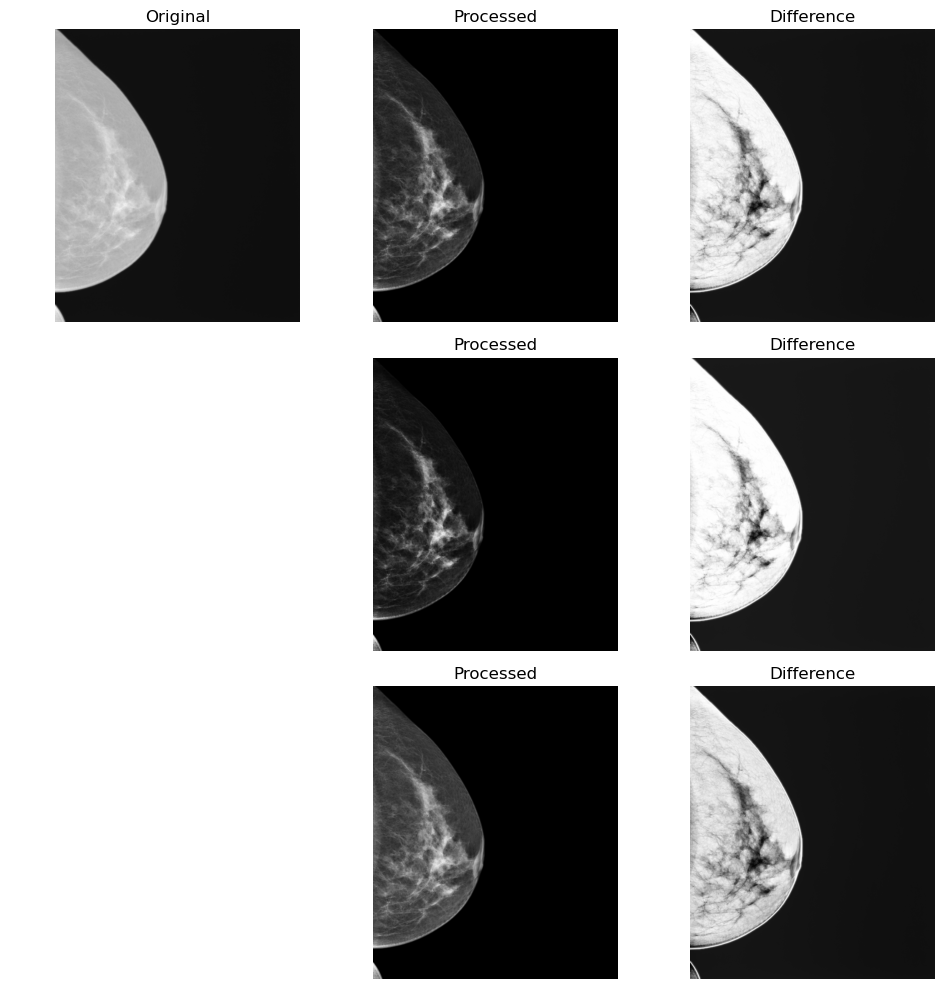

In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 3, figsize=(10, 10))
ax[0,0].imshow(original, vmin=mammo.image.min, vmax=mammo.image.max, cmap='gray')
ax[0,0].set_title('Original')
ax[0,0].axis('off')

ax[0,1].imshow(img_0.to_numpy(), vmin=mammo.image.min, vmax=mammo.image.max, cmap='gray')
ax[0,1].set_title('Processed')
ax[0,1].axis('off')
plt.tight_layout()

ax[0,2].imshow(np.abs(img_0.to_numpy()-original), cmap='gray')
ax[0,2].set_title('Difference')
ax[0,2].axis('off')
plt.tight_layout()

######
ax[1,0].axis('off')
plt.tight_layout()

ax[1,1].imshow(img_1.to_numpy(), vmin=mammo.image.min, vmax=mammo.image.max, cmap='gray')
ax[1,1].set_title('Processed')
ax[1,1].axis('off')
plt.tight_layout()

ax[1,2].imshow(np.abs(img_1.to_numpy()-original), cmap='gray')
ax[1,2].set_title('Difference')
ax[1,2].axis('off')
plt.tight_layout()

######
ax[2,0].axis('off')
plt.tight_layout()

ax[2,1].imshow(img_2.to_numpy(), vmin=mammo.image.min, vmax=mammo.image.max, cmap='gray')
ax[2,1].set_title('Processed')
ax[2,1].axis('off')
plt.tight_layout()

ax[2,2].imshow(np.abs(img_2.to_numpy()-original), cmap='gray')
ax[2,2].set_title('Difference')
ax[2,2].axis('off')
plt.tight_layout()